## PACOTES ##

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import json
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from scipy.stats import norm
from IPython.display import display

## CÓDIGO ##

In [2]:
# Caminhos do projeto
BASE_PATH = Path("thoracic_surgery_base_modelo_statsmodels.csv")
OUTPUT_DIR = Path("outputs")

# Arquivos gerados anteriormente
CAMINHO_MODELO_FINAL = OUTPUT_DIR / "modelo_final.pkl"
CAMINHO_VARIAVEIS_FINAIS = OUTPUT_DIR / "variaveis_finais.json"

# Arquivos que serão gerados neste Programa 5
CAMINHO_RESIDUOS = OUTPUT_DIR / "residuos.csv"
CAMINHO_GRAFICO_ENVELOPE = OUTPUT_DIR / "grafico_envelope.png"

# Variável resposta
VAR_RESPOSTA = "obito_1_ano"

In [3]:
# Carregar base
dados = pd.read_csv(BASE_PATH)

# Carregar informações do modelo final
with open(CAMINHO_VARIAVEIS_FINAIS, "r", encoding="utf-8") as arquivo:
    info_finais = json.load(arquivo)

# Carregar modelo final ajustado
resultado_final = sm.load(str(CAMINHO_MODELO_FINAL))

print("Base, modelo final e variáveis finais carregados com sucesso.")

print("\nDimensão da base:")
print(dados.shape)

print("\nVariáveis do modelo final:")
display(pd.DataFrame({"variavel": info_finais["variaveis_modelo_final"]}))

Base, modelo final e variáveis finais carregados com sucesso.

Dimensão da base:
(470, 26)

Variáveis do modelo final:


,variavel
0,constante
1,"C(diagnostico, Treatment(reference='DGN3'))[T...."
2,"C(diagnostico, Treatment(reference='DGN3'))[T...."
3,"C(diagnostico, Treatment(reference='DGN3'))[T...."
4,"C(diagnostico, Treatment(reference='DGN3'))[T...."
5,"C(diagnostico, Treatment(reference='DGN3'))[T...."
6,"C(diagnostico, Treatment(reference='DGN3'))[T...."
7,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."
8,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."
9,"C(tamanho_tumor_tnm, Treatment(reference='OC11..."


In [4]:
# Variável resposta
y = dados[VAR_RESPOSTA].astype(float)

# Matriz de covariáveis do modelo final
variaveis_modelo_final = info_finais["variaveis_modelo_final"]

X_final = dados[variaveis_modelo_final].copy()

# Garantir formato numérico
for coluna in X_final.columns:
    X_final[coluna] = pd.to_numeric(X_final[coluna], errors="coerce")

# Verificar valores ausentes
faltantes = X_final.isna().sum()
faltantes = faltantes[faltantes > 0]

if len(faltantes) > 0:
    print("Variáveis com valores ausentes:")
    display(faltantes.to_frame("n_faltantes"))
    raise ValueError("Existem valores ausentes em X_final.")

print("Dimensão de y:")
print(y.shape)

print("\nDimensão de X_final:")
print(X_final.shape)

display(X_final.head())

Dimensão de y:
(470,)

Dimensão de X_final:
(470, 13)


,constante,"C(diagnostico, Treatment(reference='DGN3'))[T.DGN1]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN2]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN4]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN5]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN6]","C(diagnostico, Treatment(reference='DGN3'))[T.DGN8]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC12]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC13]","C(tamanho_tumor_tnm, Treatment(reference='OC11'))[T.OC14]",dispneia_antes_cirurgia,diabetes_mellitus_tipo_2,tabagismo
0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [5]:
# Probabilidades ajustadas
probabilidades_ajustadas = resultado_final.predict(X_final)

# Medidas de influência para obter h_ii
influencia = resultado_final.get_influence(observed=True)

# Alavancagem
h_ii = influencia.hat_matrix_diag

# Proteção numérica para evitar divisão por zero
h_ii_ajustado = np.clip(h_ii, 0, 0.999999)

# Resíduos
residuo_resposta = resultado_final.resid_response
residuo_pearson = resultado_final.resid_pearson
residuo_deviance = resultado_final.resid_deviance

# Resíduo de deviance padronizado
residuo_deviance_padronizado = residuo_deviance / np.sqrt(1 - h_ii_ajustado)

# Tabela de resíduos
tabela_residuos = pd.DataFrame({
    "indice": dados.index,
    "obito_observado": y.values,
    "probabilidade_ajustada": probabilidades_ajustadas,
    "residuo_resposta": residuo_resposta,
    "residuo_pearson": residuo_pearson,
    "residuo_deviance": residuo_deviance,
    "h_ii": h_ii,
    "residuo_deviance_padronizado": residuo_deviance_padronizado
})

display(tabela_residuos.head())

print("Resumo dos resíduos de deviance padronizados:")
display(
    tabela_residuos["residuo_deviance_padronizado"]
    .describe()
    .to_frame()
)

,indice,obito_observado,probabilidade_ajustada,residuo_resposta,residuo_pearson,residuo_deviance,h_ii,residuo_deviance_padronizado
0,0,0.0,0.465570,-0.465570,-0.933356,-1.119424,0.077501,-1.165498
1,1,0.0,0.119341,-0.119341,-0.368121,-0.504152,0.005270,-0.505485
2,2,0.0,0.084697,-0.084697,-0.304195,-0.420714,0.006136,-0.422010
3,3,0.0,0.026848,-0.026848,-0.166100,-0.233304,0.007712,-0.234209
4,4,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863


Resumo dos resíduos de deviance padronizados:


,residuo_deviance_padronizado
count,470.000000
mean,-0.172445
std,0.866996
min,-1.792323
25%,-0.505485
50%,-0.422010
75%,-0.282865
max,2.561678


In [6]:
# Observações com resíduos de deviance padronizados mais extremos

tabela_residuos["abs_residuo_deviance_padronizado"] = (
    tabela_residuos["residuo_deviance_padronizado"].abs()
)

residuos_extremos = tabela_residuos.sort_values(
    by="abs_residuo_deviance_padronizado",
    ascending=False
).reset_index(drop=True)

print("Observações com maiores resíduos de deviance padronizados:")
display(residuos_extremos.head(15))

print("\nQuantidade de observações com |resíduo padronizado| > 2:")
print((tabela_residuos["abs_residuo_deviance_padronizado"] > 2).sum())

print("\nQuantidade de observações com |resíduo padronizado| > 3:")
print((tabela_residuos["abs_residuo_deviance_padronizado"] > 3).sum())

Observações com maiores resíduos de deviance padronizados:


,indice,obito_observado,probabilidade_ajustada,residuo_resposta,residuo_pearson,residuo_deviance,h_ii,residuo_deviance_padronizado,abs_residuo_deviance_padronizado
0,152,1.0,0.038834,0.961166,4.974989,2.548904,0.009949,2.561678,2.561678
1,302,1.0,0.084291,0.915709,3.296008,2.224177,0.041351,2.271640,2.271640
2,27,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
3,340,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
4,173,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
5,191,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
6,251,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
7,151,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
8,4,1.0,0.084697,0.915303,3.287370,2.222015,0.006136,2.228863,2.228863
9,67,1.0,0.113420,0.886580,2.795849,2.086459,0.023187,2.111078,2.111078



Quantidade de observações com |resíduo padronizado| > 2:
29

Quantidade de observações com |resíduo padronizado| > 3:
0


Número de simulações realizadas com sucesso: 250


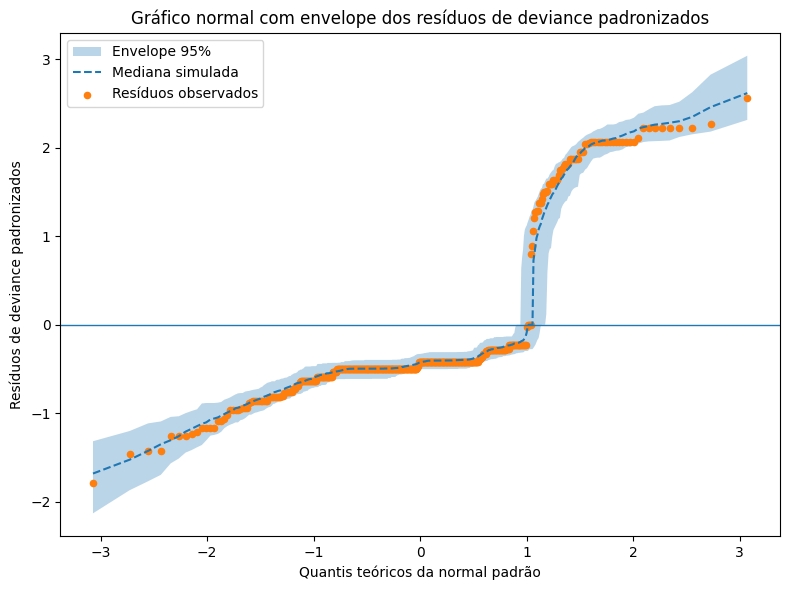

Gráfico salvo em:
outputs\grafico_envelope.png


In [7]:
# Gráfico normal com envelope para os resíduos de deviance padronizados

np.random.seed(42)

B = 250  # número de simulações
n = len(y)

prob_simulacao = np.asarray(probabilidades_ajustadas)
prob_simulacao = np.clip(prob_simulacao, 1e-6, 1 - 1e-6)

residuos_observados_ordenados = np.sort(residuo_deviance_padronizado)

quantis_normais = norm.ppf((np.arange(1, n + 1) - 0.5) / n)

residuos_simulados_ordenados = []

warnings.filterwarnings("ignore")

for b in range(B):
    
    try:
        # Simular nova resposta Bernoulli com base nas probabilidades ajustadas
        y_sim = np.random.binomial(1, prob_simulacao)
        
        # Ajustar modelo com a resposta simulada
        modelo_sim = sm.GLM(
            y_sim,
            X_final,
            family=sm.families.Binomial()
        )
        
        resultado_sim = modelo_sim.fit(maxiter=200)
        
        # Calcular resíduos simulados
        influencia_sim = resultado_sim.get_influence(observed=True)
        h_sim = influencia_sim.hat_matrix_diag
        h_sim = np.clip(h_sim, 0, 0.999999)
        
        residuo_dev_sim = resultado_sim.resid_deviance
        residuo_dev_pad_sim = residuo_dev_sim / np.sqrt(1 - h_sim)
        
        residuos_simulados_ordenados.append(np.sort(residuo_dev_pad_sim))
    
    except Exception:
        continue

warnings.filterwarnings("default")

residuos_simulados_ordenados = np.array(residuos_simulados_ordenados)

print(f"Número de simulações realizadas com sucesso: {residuos_simulados_ordenados.shape[0]}")

if residuos_simulados_ordenados.shape[0] < 30:
    raise ValueError(
        "Poucas simulações foram concluídas com sucesso. "
        "Verifique possíveis problemas de ajuste no modelo."
    )

# Limites do envelope
limite_inferior = np.percentile(residuos_simulados_ordenados, 2.5, axis=0)
limite_medio = np.percentile(residuos_simulados_ordenados, 50, axis=0)
limite_superior = np.percentile(residuos_simulados_ordenados, 97.5, axis=0)

# Construção do gráfico
plt.figure(figsize=(8, 6))

plt.fill_between(
    quantis_normais,
    limite_inferior,
    limite_superior,
    alpha=0.3,
    label="Envelope 95%"
)

plt.plot(
    quantis_normais,
    limite_medio,
    linestyle="--",
    label="Mediana simulada"
)

plt.scatter(
    quantis_normais,
    residuos_observados_ordenados,
    s=20,
    label="Resíduos observados"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Quantis teóricos da normal padrão")
plt.ylabel("Resíduos de deviance padronizados")
plt.title("Gráfico normal com envelope dos resíduos de deviance padronizados")
plt.legend()
plt.tight_layout()

plt.savefig(CAMINHO_GRAFICO_ENVELOPE, dpi=300, bbox_inches="tight")

plt.show()

print("Gráfico salvo em:")
print(CAMINHO_GRAFICO_ENVELOPE)

In [8]:
# Salvar tabela de resíduos

tabela_residuos.to_csv(
    CAMINHO_RESIDUOS,
    index=False,
    encoding="utf-8-sig"
)

print("Tabela de resíduos salva em:")
print(CAMINHO_RESIDUOS)

Tabela de resíduos salva em:
outputs\residuos.csv
